# NATURAL GAS PRICE ANALYSIS

**Importing Libraries**

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

**Importing Database**

In [60]:
df = pd.read_csv(r"C:\Users\harsh\Downloads\Nat_Gas.csv")

In [61]:
df.head()

,Dates,Prices
0,10/31/20,10.1
1,11/30/20,10.3
2,12/31/20,11.0
3,1/31/21,10.9
4,2/28/21,10.9


In [62]:
df.tail()

,Dates,Prices
43,5/31/24,11.4
44,6/30/24,11.5
45,7/31/24,11.6
46,8/31/24,11.5
47,9/30/24,11.8


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Dates   48 non-null     str    
 1   Prices  48 non-null     float64
dtypes: float64(1), str(1)
memory usage: 900.0 bytes


**Convert Dates to Datetime**

In [64]:
df["Dates"] = pd.to_datetime(df["Dates"])

C:\Users\harsh\AppData\Local\Temp\ipykernel_3064\632498050.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dates"] = pd.to_datetime(df["Dates"])


**Sort Date From Oldest To Newest**

In [65]:
df = df.sort_values("Dates")

In [66]:
df.head()

,Dates,Prices
0,2020-10-31,10.1
1,2020-11-30,10.3
2,2020-12-31,11.0
3,2021-01-31,10.9
4,2021-02-28,10.9


### Visualising Natural Gas Prices

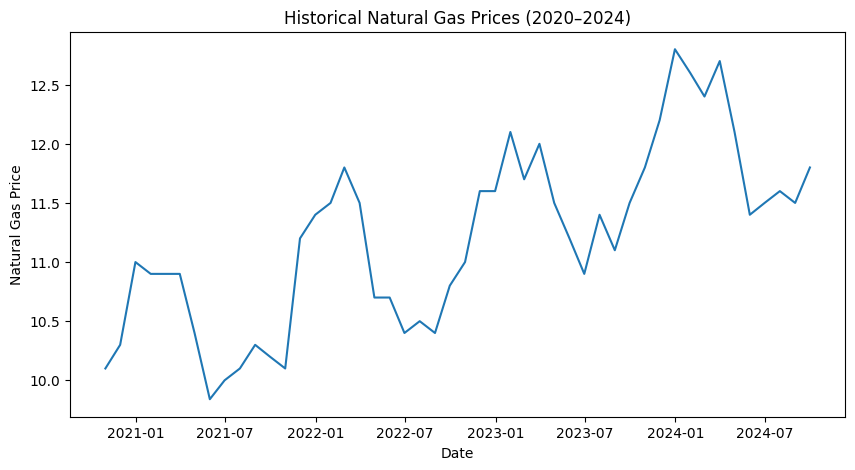

In [67]:
plt.figure(figsize=(10,5))
plt.plot(df["Dates"], df["Prices"])
plt.xlabel("Date")
plt.ylabel("Natural Gas Price")
plt.title("Historical Natural Gas Prices (2020–2024)")
plt.show()

**Converting Time To Numeric Index**

In [68]:
df["t"] = np.arange(len(df))

**Creating A Prediction Model - Polynomial Regression Model**

*Using 3 Degree because it is cubic polynomial that fits curves*

In [69]:
coefficients = np.polyfit(df["t"], df["Prices"], 3)

**Converting coefficients into a model**

In [70]:
model = np.poly1d(coefficients)

**Forecasting 12 months into future**

In [71]:
future_t = np.arange(len(df), len(df)+12)

**Price Prediction**

In [72]:
future_prices = model(future_t)

**Generating Future Dates**

In [73]:
last_date = df["Dates"].max()

**Generating Future Months**

In [74]:
future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthEnd(1),
    periods=12,
    freq="ME"
)

**Creating Forecasting Table**

In [75]:
forecast_df = pd.DataFrame({
    "Dates": future_dates,
    "Prices": future_prices
})

**Combining Past And Future Values**

In [76]:
combined = pd.concat([df[["Dates","Prices"]], forecast_df])

### Comparison Between Past And Future Prices

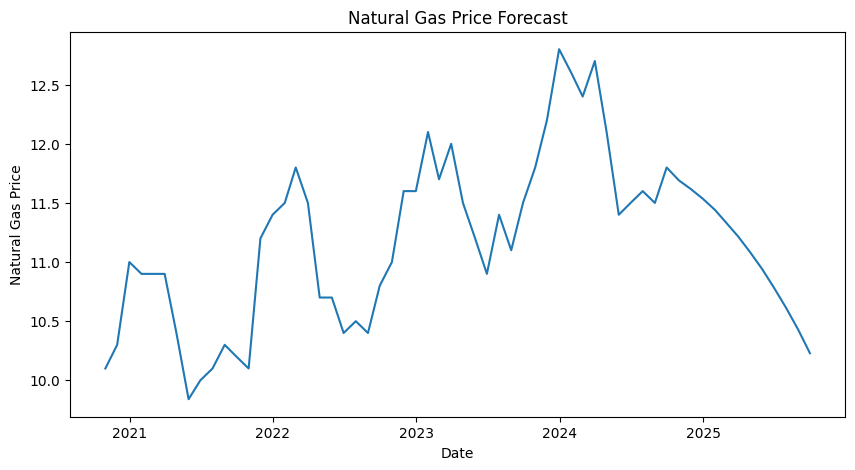

In [77]:
plt.figure(figsize=(10,5))
plt.plot(combined["Dates"], combined["Prices"])
plt.xlabel("Date")
plt.ylabel("Natural Gas Price")
plt.title("Natural Gas Price Forecast")
plt.show()

**Converting Time To Numeric Index**

In [78]:
def estimate_price(date_input):

    date = pd.to_datetime(date_input)

    start_date = df["Dates"].min()

    months_passed = (date.year - start_date.year) * 12 + (date.month - start_date.month)

    price = model(months_passed)

    return float(price)

### Estimating Prices

In [79]:
estimate_price("2025-03-09")

11.217003165126675

### Conclusion

**The historical natural gas price data was analyzed using time-series visualization and polynomial regression modeling. The dataset shows cyclical fluctuations and an overall upward trend. A cubic polynomial regression model was used to capture this trend and extrapolate prices for the next 12 months.**

**The implemented function allows estimation of natural gas prices for any given date, which can be useful for evaluating long-term storage contracts.**

**Factors affecting natural gas prices include seasonal demand, weather conditions, supply levels, and geopolitical factors.**

## STL DECOMPOSITION

#### Trend — the long-term direction of prices
#### Seasonal — repeating cycles (for gas, winter demand spikes)
#### Residual — random noise that the model cannot explain

*Importing STL*

In [84]:
from statsmodels.tsa.seasonal import STL

**Arranging Dataset Format**

In [87]:
df = pd.read_csv(r"C:\Users\harsh\Downloads\Nat_Gas.csv")

df["Dates"] = pd.to_datetime(df["Dates"])

df.set_index("Dates", inplace=True)

df = df.sort_index()

C:\Users\harsh\AppData\Local\Temp\ipykernel_3064\2550173476.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dates"] = pd.to_datetime(df["Dates"])


**Applying STL Decomposition**

In [88]:
stl = STL(df["Prices"], period=12)
result = stl.fit()

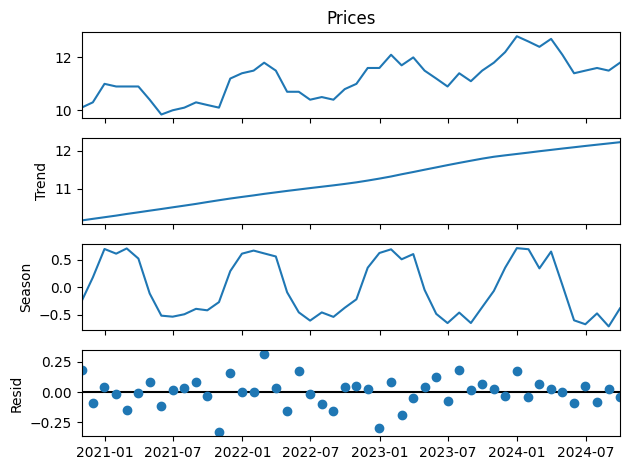

In [89]:
result.plot()
plt.show()

**THE ABOVE FOUR GRAPHS ARE AS FOLLOWS:**

1. **Observed Data:** The raw data from the market
2. **Trend:** This shows the overall direction of prices
   Here trend is increasing means the market price level is increasing over time.
   Reasons: Inflation, Production Cost
3. **Seasonal:** In Winter the demand usually Increases, where in Spring it Decreases, In Summers Demand is Moderate, Autumn shows as          Storage Buildup.
4. **Residual:** This represents random market shocks. Reasons: Sudden Weather events, Supply disruptions

### Seasonal Patterns In Gas Prices

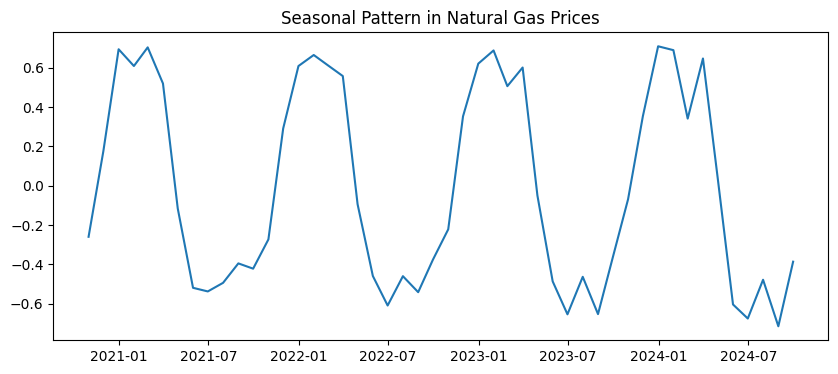

In [90]:
plt.figure(figsize=(10,4))
plt.plot(result.seasonal)
plt.title("Seasonal Pattern in Natural Gas Prices")
plt.show()

**Natural gas demand exhibits strong seasonal patterns driven primarily by heating demand during winter months. STL decomposition was applied to separate the time series into trend, seasonal, and residual components. The seasonal component reveals recurring annual fluctuations consistent with increased winter consumption and lower demand during warmer months.**

## Conclusion

In this project, historical natural gas price data from October 2020 to September 2024 was analyzed to understand price behavior and develop a method for estimating prices for both past and future dates. The dataset consisted of monthly market prices representing the cost of natural gas delivered at the end of each calendar month. The analysis began with data preparation, where the dataset was imported, the date column was converted into a proper datetime format, and the data was organized chronologically to ensure accurate time-series analysis.

Exploratory data analysis was conducted through visualization of the historical price series. The visualization revealed that natural gas prices exhibit fluctuations over time rather than following a simple linear pattern. These fluctuations suggest the presence of underlying trends and potential seasonal effects, which are common in energy markets due to factors such as weather conditions, changes in supply and demand, storage levels, and geopolitical events.

To model the long-term behavior of natural gas prices, a polynomial regression approach was applied. By converting the time dimension into a numerical index, a polynomial model was fitted to capture the nonlinear trend present in the data. This model was then used to extrapolate prices beyond the available dataset, allowing price estimates to be generated for future dates. The polynomial regression provided a smooth curve representing the overall trend in natural gas prices and enabled the creation of a function capable of estimating the price for any given date.

In addition to trend modeling, Seasonal-Trend Decomposition using Loess (STL) was applied to further analyze the structure of the time series. STL decomposition separates the observed price data into three components: trend, seasonal, and residual. The trend component captures the long-term movement of prices, while the seasonal component reveals recurring patterns that repeat over time, such as potential increases in demand during colder months when heating consumption rises. The residual component represents irregular fluctuations that cannot be explained by the trend or seasonal effects and may reflect unpredictable market factors.

The combination of polynomial regression and STL decomposition provided both predictive capability and interpretability. Polynomial regression enabled forecasting and price estimation, while STL decomposition offered deeper insight into the underlying structure of the data by isolating trend and seasonal patterns. Together, these techniques form a robust analytical framework for examining commodity price behavior.

Overall, this project demonstrates how time-series analysis techniques can be applied to financial and commodity market data using Python. The approach highlights the importance of data visualization, statistical modeling, and decomposition techniques in understanding market dynamics and generating price estimates. Such analytical methods are widely used in quantitative finance and energy markets to support decision-making, risk management, and pricing strategies for long-term contracts.